In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

#pytorch libraries
import torch
from torch import nn, optim
from torchvision.transforms import ToTensor
import torch.nn.functional as F
from torch.utils.data import Dataset,ConcatDataset,DataLoader
from torchvision import transforms 
#Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

<a id="00"></a>
# <p style="background-color:#002663;height: 60px;text-align: center;vertical-align: middle;line-height: 60px;;font-family:courier;color:#FFFFFF;font-size:120%;text-align:center;border-radius:12px 12px;"> Auto Encoder with MNIST Dataset Experiment </p>
<div style="font-family: courier; font-size:18px">
 This notebook implements a simple Autoencoder Model in pytorch. Than, some experiments are tested 
<li> MNIST Dataset Class
<li> Autoencoder Model Pytorch
<li> Run Training
<li> Planing Model Results Testing
<li> Adding Noise to the Samples to check denoising capabilities of the model
<li> Adding occlusion to the Samples to check capabilities of the model to remove it
<b>

In [2]:
class MNISTdataset(Dataset):
    """ Mnist Dataset class"""
    def __init__(self, data, transform = None):
        
        self.X = (data.drop('label', axis =1).values/255)
        self.y = data['label'].values.reshape(-1,1)
        self.n_samples = data.shape[0]
        
        self.transform = transform 
    
    def __getitem__(self, index):
        X,y = self.X[index], self.y[index]
        
        X = torch.from_numpy(X)
            
        return (X,y)
        
    def __len__(self):
        return self.n_samples

In [3]:
class CFG():
    learning_rate = 1e-2
    
    batch_size  = 32


# <p style="background-color:#002663;height: 60px;text-align: center;vertical-align: middle;line-height: 60px;;font-family:courier;color:#FFFFFF;font-size:120%;text-align:center;border-radius:12px 12px;"> Loading Dataset MNIST with a Dataloader</p>
<div style="font-family: courier; font-size:18px">

In [4]:
train_df = pd.read_csv('../input/digit-recognizer/train.csv',dtype=np.float32)
dataset_mnist = MNISTdataset(train_df)

train_loader = DataLoader(dataset_mnist, batch_size  = CFG.batch_size,  shuffle = True)

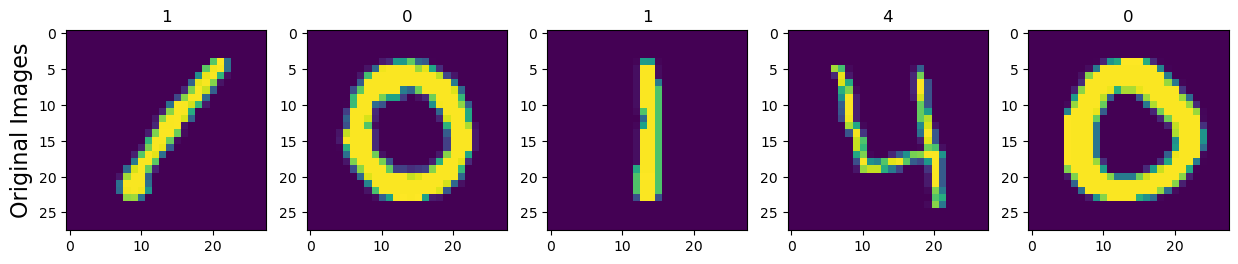

In [5]:
fig, ax = plt.subplots(nrows = 1, ncols = 5,  figsize = (15,8))
for i in range(5):
    image, y = dataset_mnist.__getitem__(i)
    ax[i].imshow(image.reshape((-1, 28, 28,1)).squeeze(), cmap="viridis") # Squeeze removes length (1,28,28) -> (28,28)
    ax[i].set_title(int(y))

ax[0].set_ylabel('Original Images', fontdict= {'fontsize':16});   
# ax[1,0].set_ylabel('Augmented Images',fontdict= {'fontsize':16})




# <p style="background-color:#002663;height: 60px;text-align: center;vertical-align: middle;line-height: 60px;;font-family:courier;color:#FFFFFF;font-size:120%;text-align:center;border-radius:12px 12px;"> Autoencoder Model</p>
<div style="font-family: courier; font-size:18px">

In [6]:
class autoEncoderMNIST(nn.Module):
    
    def __init__(self, input_layer = 784, enc_layer = 250, latent_layer = 50):
        super().__init__()
        
        # input layer
        self.input = nn.Linear(input_layer, enc_layer)
        
        #Encoder layer
        self.encoder = nn.Linear(enc_layer, latent_layer)
        
        # Latent\bottelneck layer
        self.bneck = nn.Linear(latent_layer, enc_layer)
        
        #decoder layer
        self.decoder = nn.Linear(enc_layer, input_layer)
        
    def forward(self, x):
        x = F.relu(self.input(x))
        x = F.relu(self.encoder(x))        
        x = F.relu(self.bneck(x))
        x = torch.sigmoid(self.decoder(x))
        return x



# Testing Model

In [7]:
model_autoEnc = autoEncoderMNIST(input_layer = 784, enc_layer = 250, latent_layer = 50)
loss = nn.MSELoss()
optmizer = torch.optim.AdamW(model_autoEnc.parameters(), lr = CFG.learning_rate)

dataset_mnist = MNISTdataset(train_df)


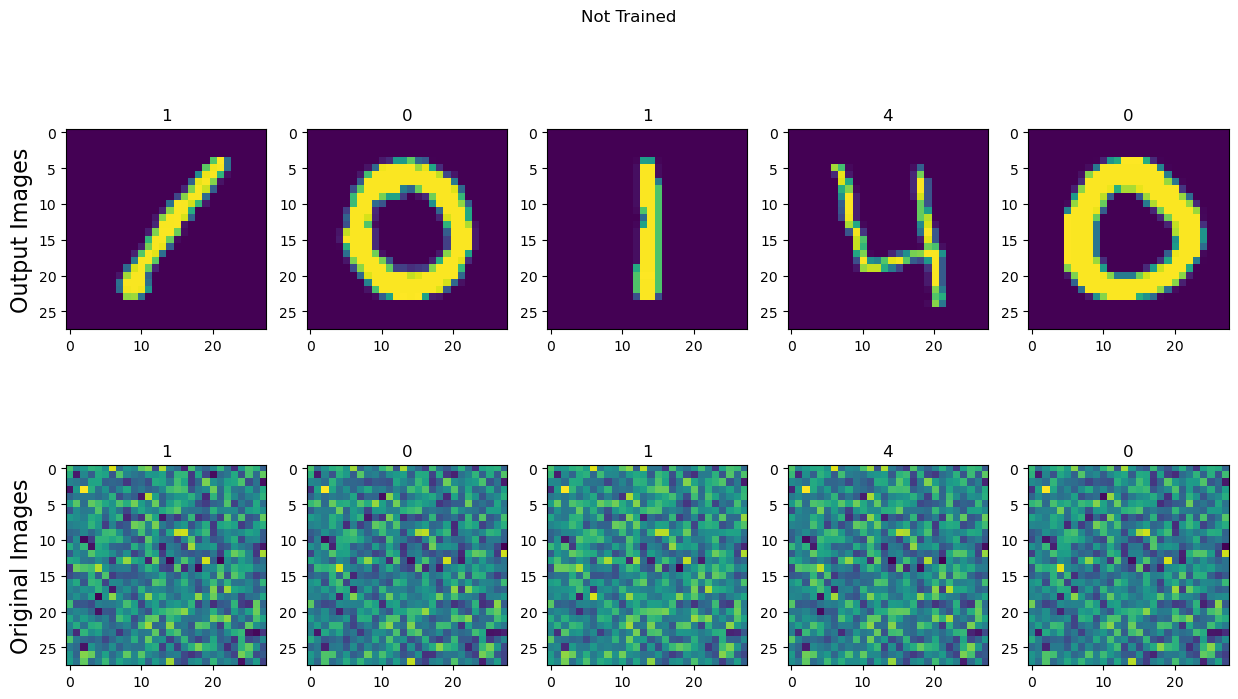

In [8]:
fig, ax = plt.subplots(nrows = 2, ncols = 5,  figsize = (15,8))
for i in range(5):
    image, y = dataset_mnist.__getitem__(i)
    ax[0,i].imshow(image.reshape((-1, 28, 28,1)).squeeze(), cmap="viridis")
    ax[0,i].set_title(int(y))
    
    img_test = model_autoEnc(image)
    
    ax[1,i].imshow(img_test.detach().numpy().reshape(28,28), cmap="viridis")
    ax[1,i].set_title(int(y))

plt.suptitle('Not Trained')
ax[1,0].set_ylabel('Original Images', fontdict= {'fontsize':16});
ax[0,0].set_ylabel('Output Images', fontdict= {'fontsize':16});



# <p style="background-color:#002663;height: 60px;text-align: center;vertical-align: middle;line-height: 60px;;font-family:courier;color:#FFFFFF;font-size:120%;text-align:center;border-radius:12px 12px;"> Train Function and Runing</p>
<div style="font-family: courier; font-size:18px">

In [9]:
def train_model(train_loader, model, optmizer,loss_func, epoch, verbose = True ):
    
    
    losses = []
    
    for e in range(epoch):
        btch_loss =[]
        for X, y in train_loader:

            X_hat = model(X)
            loss = loss_func(X_hat,X)

            optmizer.zero_grad()
            loss.backward()
            optmizer.step()
            btch_loss.append(loss.item())

        losses.append(np.mean(btch_loss))
        if verbose: print(f'[{e+1}/{epoch}] -> Mean Loss of epoch {e+1} : {np.round(losses[-1],3)}')
                
    return model, losses


## Training Model

In [10]:
model_autoEnc = autoEncoderMNIST(input_layer = 784, enc_layer = 512, latent_layer = 128)
loss_function = nn.MSELoss()
optmizer = torch.optim.AdamW(model_autoEnc.parameters(), lr = CFG.learning_rate)

dataset_mnist = MNISTdataset(train_df)
train_loader = DataLoader(dataset_mnist, batch_size  = CFG.batch_size,  shuffle = True)

model, losses = train_model(train_loader = train_loader,
                            model = model_autoEnc, 
                            optmizer = optmizer,
                            loss_func = loss_function, 
                            epoch = 5, 
                            verbose = True )

[1/5] -> Mean Loss of epoch 1 : 0.026
[2/5] -> Mean Loss of epoch 2 : 0.019
[3/5] -> Mean Loss of epoch 3 : 0.019
[4/5] -> Mean Loss of epoch 4 : 0.018
[5/5] -> Mean Loss of epoch 5 : 0.018



# <p style="background-color:#002663;height: 60px;text-align: center;vertical-align: middle;line-height: 60px;;font-family:courier;color:#FFFFFF;font-size:120%;text-align:center;border-radius:12px 12px;"> Plain Results</p>
<div style="font-family: courier; font-size:18px">

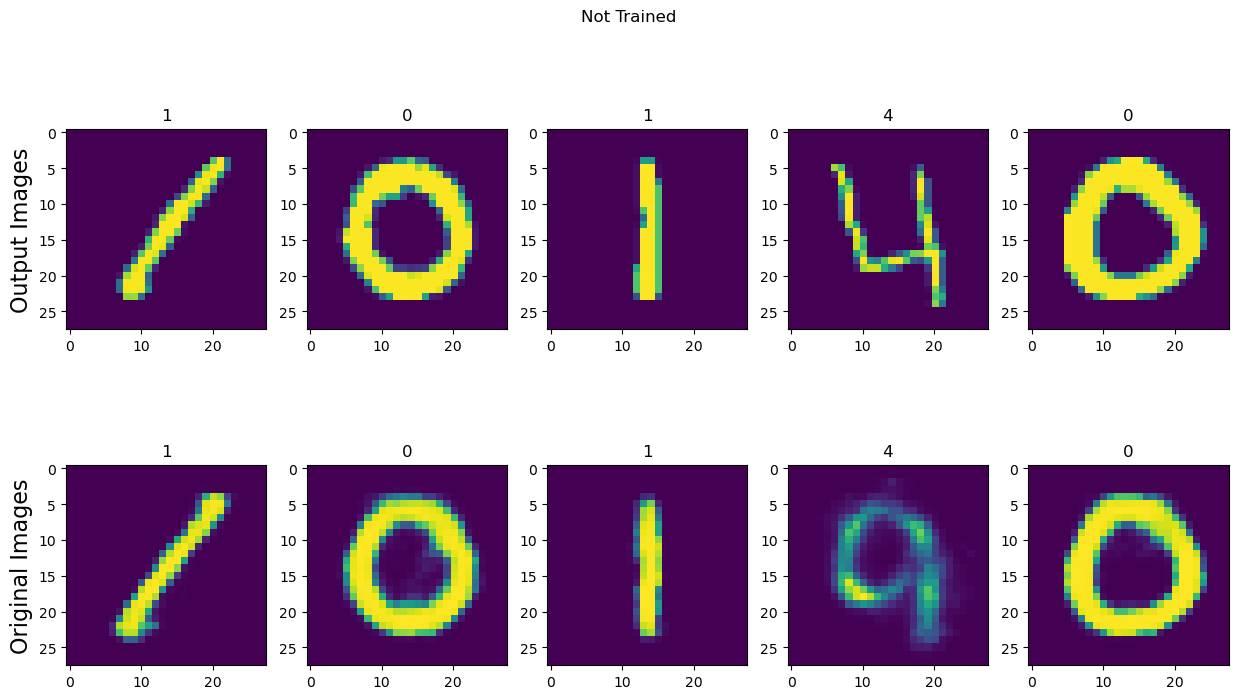

In [11]:
dataset_mnist = MNISTdataset(train_df)
fig, ax = plt.subplots(nrows = 2, ncols = 5,  figsize = (15,8))
for i in range(5):
    image, y = dataset_mnist.__getitem__(i)
    ax[0,i].imshow(image.reshape((-1, 28, 28,1)).squeeze(), cmap="viridis")
    ax[0,i].set_title(int(y))
    model_autoEnc.eval()
    img_test = model_autoEnc(image)
    
    ax[1,i].imshow(img_test.detach().numpy().reshape(28,28), cmap="viridis")
    ax[1,i].set_title(int(y))

plt.suptitle('Not Trained')
ax[1,0].set_ylabel('Original Images', fontdict= {'fontsize':16});
ax[0,0].set_ylabel('Output Images', fontdict= {'fontsize':16});

# <p style="background-color:#002663;height: 60px;text-align: center;vertical-align: middle;line-height: 60px;;font-family:courier;color:#FFFFFF;font-size:120%;text-align:center;border-radius:12px 12px;"> Denoising Results</p>
<div style="font-family: courier; font-size:18px">

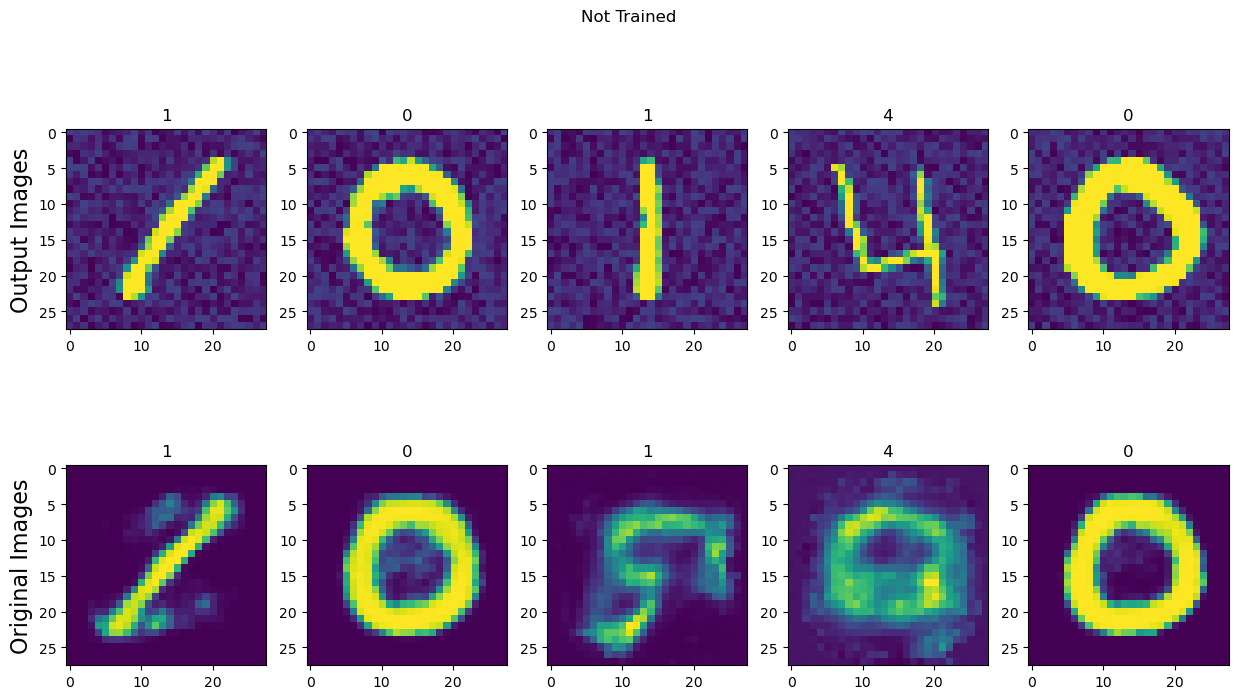

In [12]:
noise_factor  = 5
dataset_mnist = MNISTdataset(train_df)

fig, ax = plt.subplots(nrows = 2, ncols = 5,  figsize = (15,8))
for i in range(5):
    image, y = dataset_mnist.__getitem__(i)
    
    #Adding Noise to the image
    image = image + torch.rand_like(image)/noise_factor
    image[image>1] = 1
    
    ax[0,i].imshow(image.reshape((-1, 28, 28,1)).squeeze(), cmap="viridis")
    ax[0,i].set_title(int(y))
    model_autoEnc.eval()
    img_test = model_autoEnc(image)
    
    ax[1,i].imshow(img_test.detach().numpy().reshape(28,28), cmap="viridis")
    ax[1,i].set_title(int(y))

plt.suptitle('Not Trained')
ax[1,0].set_ylabel('Original Images', fontdict= {'fontsize':16});
ax[0,0].set_ylabel('Output Images', fontdict= {'fontsize':16});

# <p style="background-color:#002663;height: 60px;text-align: center;vertical-align: middle;line-height: 60px;;font-family:courier;color:#FFFFFF;font-size:120%;text-align:center;border-radius:12px 12px;"> Occlusion Results</p>
<div style="font-family: courier; font-size:18px">

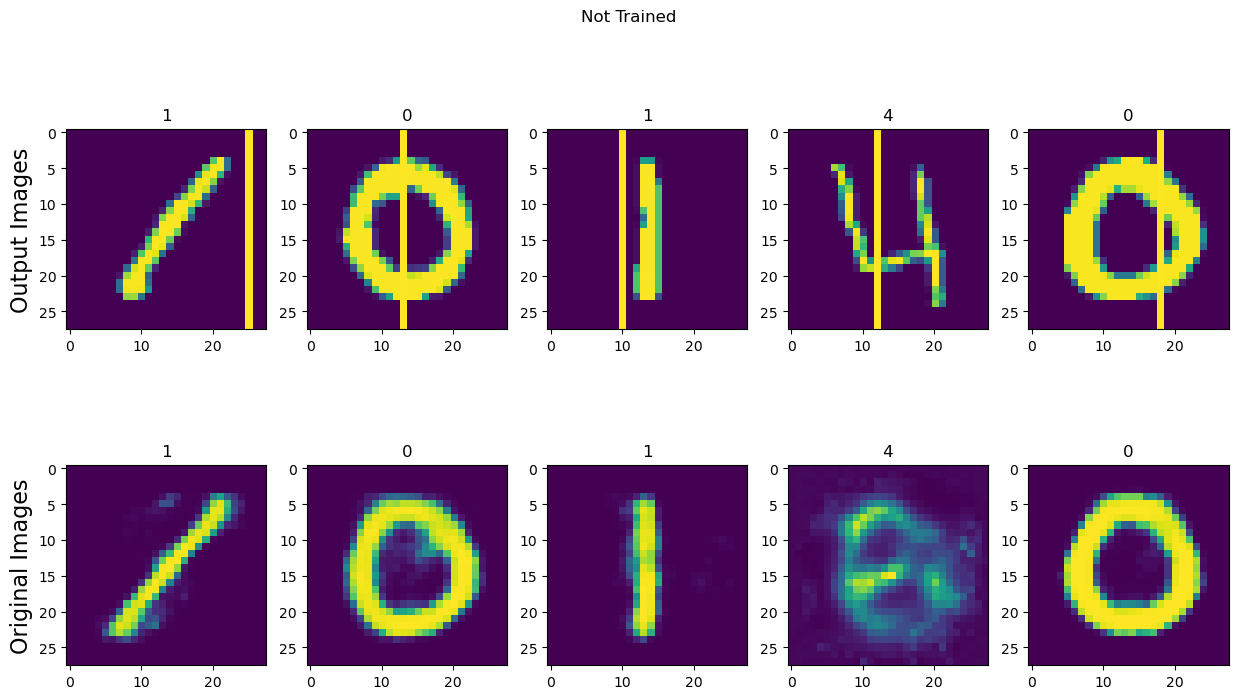

In [13]:
dataset_mnist = MNISTdataset(train_df)

fig, ax = plt.subplots(nrows = 2, ncols = 5,  figsize = (15,8))
for i in range(5):
    image, y = dataset_mnist.__getitem__(i)
    
    # Adding Occlusion
    val = np.random.choice(range(8,26))
    image.view(28,28)[:,val:val+1] = 1
    
    ax[0,i].imshow(image.reshape((-1, 28, 28,1)).squeeze(), cmap="viridis")
    ax[0,i].set_title(int(y))
    model_autoEnc.eval()
    img_test_2 = model_autoEnc(image)
    
    ax[1,i].imshow(img_test_2.detach().numpy().reshape(28,28), cmap="viridis")
    ax[1,i].set_title(int(y))

plt.suptitle('Not Trained')
ax[1,0].set_ylabel('Original Images', fontdict= {'fontsize':16});
ax[0,0].set_ylabel('Output Images', fontdict= {'fontsize':16});